In [1]:
# Input Image
# SET PYTHONPATH to the parent directory 
import sys
import os
if os.path.abspath("..") not in sys.path:
    sys.path.append(os.path.abspath(".."))

# Set default to double 
FILTER_SIZE = 15 
MAX_ORDER = 4 # R 
sys.path

['/Users/karella/.conda/envs/hippy2d/lib/python311.zip',
 '/Users/karella/.conda/envs/hippy2d/lib/python3.11',
 '/Users/karella/.conda/envs/hippy2d/lib/python3.11/lib-dynload',
 '',
 '/Users/karella/.local/lib/python3.11/site-packages',
 '/Users/karella/.conda/envs/hippy2d/lib/python3.11/site-packages',
 '/Users/karella/Projects/rotation-invariant-neural-networks/hippy2d']

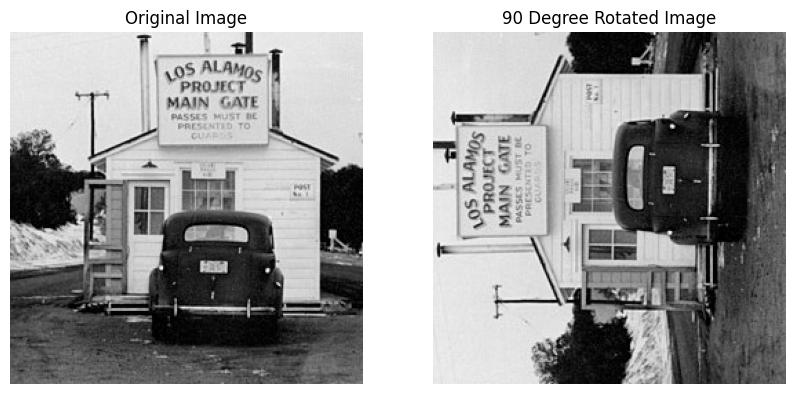

In [2]:

# Get testing image and its 90 degree rotation
import torch 
from torchvision import transforms
from hippy2d.utils import get_testing_img, get_default_complex
# Set default to double precision
torch.set_default_dtype(torch.float64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Simulate RGB channels
test_img = get_testing_img(rgb=False)
test_img = transforms.ToTensor()(test_img).to(dtype=torch.float64)
rotated_img = torch.rot90(test_img, 1, [1, 2])
# 
test_rgb_img = get_testing_img(rgb=True)
test_rgb_img = transforms.ToTensor()(test_rgb_img).to(dtype=torch.float64)
rotated_rgb_img = torch.rot90(test_img, 1, [1, 2])
# Plot the images
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(test_img.permute(1, 2, 0).numpy(), cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(rotated_img.permute(1, 2, 0).numpy(), cmap='gray')
plt.title("90 Degree Rotated Image",)
plt.axis('off')
plt.show()


In [3]:
# Generate moments 

import numpy as np
from einops import repeat, rearrange
from hippy2d.complex_invariants_2d import get_complex_monomial

# Skip symmetric moments and calculate exponents of non-symmetric moments
symmetric_polynomials = []
non_symmetric_polynomials = []
non_symmetric_exponents = []
for p in range(0, MAX_ORDER + 1):
    for q in range(0, min(MAX_ORDER + 1-p, p + 1)):
        if p == q:
            symmetric_polynomials.append((p, q))
        else:
            non_symmetric_polynomials.append((p, q))
            non_symmetric_exponents.append(p - q)
# numpy arrays
non_symmetric_exponents = np.array(non_symmetric_exponents)
coef_a = repeat(non_symmetric_exponents, 'n -> m n', m=len(non_symmetric_exponents))
coef_b = -repeat(non_symmetric_exponents, 'n -> n m', m=len(non_symmetric_exponents))
coef = np.gcd(coef_a, coef_b)
filters = [] 
# First symmetric
for (p, q) in symmetric_polynomials:
    filters.append(get_complex_monomial(FILTER_SIZE,
                                            p, q, 
                                            dtype=torch.get_default_dtype()))
# Non-symmetric
for (p, q) in non_symmetric_polynomials:
    filters.append(get_complex_monomial(FILTER_SIZE,
                                            p, q, dtype=torch.get_default_dtype()))
filters = torch.stack(filters, dim=0)[:, None]


In [4]:
coef = np.gcd(coef_a, coef_b)

coef_a = coef_a // coef
coef_b = coef_b // coef
coef_a, coef_b

(array([[1, 2, 1, 3, 2, 4],
        [1, 1, 1, 3, 1, 2],
        [1, 2, 1, 3, 2, 4],
        [1, 2, 1, 1, 2, 4],
        [1, 1, 1, 3, 1, 2],
        [1, 1, 1, 3, 1, 1]]),
 array([[-1, -1, -1, -1, -1, -1],
        [-2, -1, -2, -2, -1, -1],
        [-1, -1, -1, -1, -1, -1],
        [-3, -3, -3, -1, -3, -3],
        [-2, -1, -2, -2, -1, -1],
        [-4, -2, -4, -4, -2, -1]]))

In [5]:
#gcds = np.gcd(coef_a, coef_b)
#coef_a = coef_a // gcds
#coef_b = coef_b // gcds
#non_symmetric_exponents


In [6]:
from torch.nn.functional import conv2d

x = repeat(test_img, 'c h w -> b c h w', b=1).to(dtype=get_default_complex())
rot_x = repeat(rotated_img, 'c h w -> b c h w', b=1).to(dtype=get_default_complex())


c_channels = conv2d(x, filters, padding='valid')
rot_channels = conv2d(rot_x, filters, padding='valid')

c_symmetric_moments = torch.view_as_real(c_channels[:, :len(symmetric_polynomials)])
rot_symmetric_moments = torch.view_as_real(rot_channels[:, :len(symmetric_polynomials)])

In [7]:
c_symmetric_moments = torch.view_as_real(c_channels[:, :len(symmetric_polynomials)])
rot_symmetric_moments = torch.view_as_real(
    torch.rot90(rot_channels[:, :len(symmetric_polynomials)],
                                    k=-1,
                                    dims=[-2, -1])
)
torch.testing.assert_close(c_symmetric_moments, rot_symmetric_moments)

c_nonsymmetric_moments = c_channels[:, len(symmetric_polynomials):]
rot_nonsymmetric_moments = rot_channels[:, len(symmetric_polynomials):]

In [8]:
a = c_nonsymmetric_moments[:, :, None] ** coef_a[..., None, None]
b = c_nonsymmetric_moments[:,None, :] ** coef_b[..., None, None]
inv = a * b

def get_inv(moments): 
    return (
        (moments[:, :, None] ** coef_a[..., None, None])
        *
        (moments[:,None, :] ** coef_b[..., None, None])
    )
a = c_nonsymmetric_moments[:, :, None] ** coef_a[..., None, None]
b = c_nonsymmetric_moments[:,None, :] ** coef_b[..., None, None]
inv = a * b

In [9]:
zero_zero = lambda moments: moments[:, 0] ** 1 * moments[:, 0] ** -1

torch.testing.assert_close(zero_zero(c_nonsymmetric_moments),
                           torch.rot90(zero_zero(rot_nonsymmetric_moments), -1, [-2, -1]))

torch.testing.assert_close(zero_zero(c_nonsymmetric_moments), inv[:, 0, 0])

torch.testing.assert_close(a[:, 0, 0], c_nonsymmetric_moments[:, 0] ** 1)
torch.testing.assert_close(b[:, 0, 0], c_nonsymmetric_moments[:, 0] ** -1)

In [10]:
one_zero = lambda moments: moments[:, 0] ** 2 * moments[:, 1] ** (-1)

torch.testing.assert_close(one_zero(c_nonsymmetric_moments),
                           torch.rot90(one_zero(rot_nonsymmetric_moments), -1, [-2, -1]))

torch.testing.assert_close(one_zero(c_nonsymmetric_moments), inv[:, 0, 1])

torch.testing.assert_close(a[:, 0, 1], c_nonsymmetric_moments[:, 0] ** 2)
torch.testing.assert_close(b[:, 0, 1], c_nonsymmetric_moments[:, 1] ** (-1))

In [11]:
zero_one = lambda moments: moments[:, 1] ** 1 * moments[:, 0] ** (-2)

torch.testing.assert_close(zero_one(c_nonsymmetric_moments),
                           torch.rot90(zero_one(rot_nonsymmetric_moments), -1, [-2, -1]))

torch.testing.assert_close(zero_one(c_nonsymmetric_moments), inv[:, 1, 0])

torch.testing.assert_close(a[:, 1, 0], c_nonsymmetric_moments[:, 1] ** 1)
torch.testing.assert_close(b[:, 1, 0], c_nonsymmetric_moments[:, 0] ** (-2))

In [12]:
one_one = lambda moments: moments[:, 1] ** 2 * moments[:, 1] ** (-2)

torch.testing.assert_close(one_one(c_nonsymmetric_moments),
                           torch.rot90(one_one(rot_nonsymmetric_moments), -1, [-2, -1]))

torch.testing.assert_close(one_one(c_nonsymmetric_moments), inv[:, 1, 1])


In [13]:
torch.testing.assert_close(get_inv(c_nonsymmetric_moments),
                           torch.rot90(get_inv(rot_nonsymmetric_moments), k=-1, dims=[-2, -1]))

In [14]:
from hippy2d.flexibleconv2d import FlexInv2D

flexi_layer = FlexInv2D(
    in_channels=1,
    out_channels=20,
    filter_size=FILTER_SIZE,
    max_order=MAX_ORDER
)

torch.testing.assert_close(flexi_layer(x), 
                           torch.rot90(flexi_layer(rot_x), k=-1, dims=[-2, -1]))


In [15]:
# Test zero input 
x_zero = torch.zeros((1, 1, 256, 256), dtype=torch.float64)
assert torch.all(~flexi_layer(x_zero).isnan())

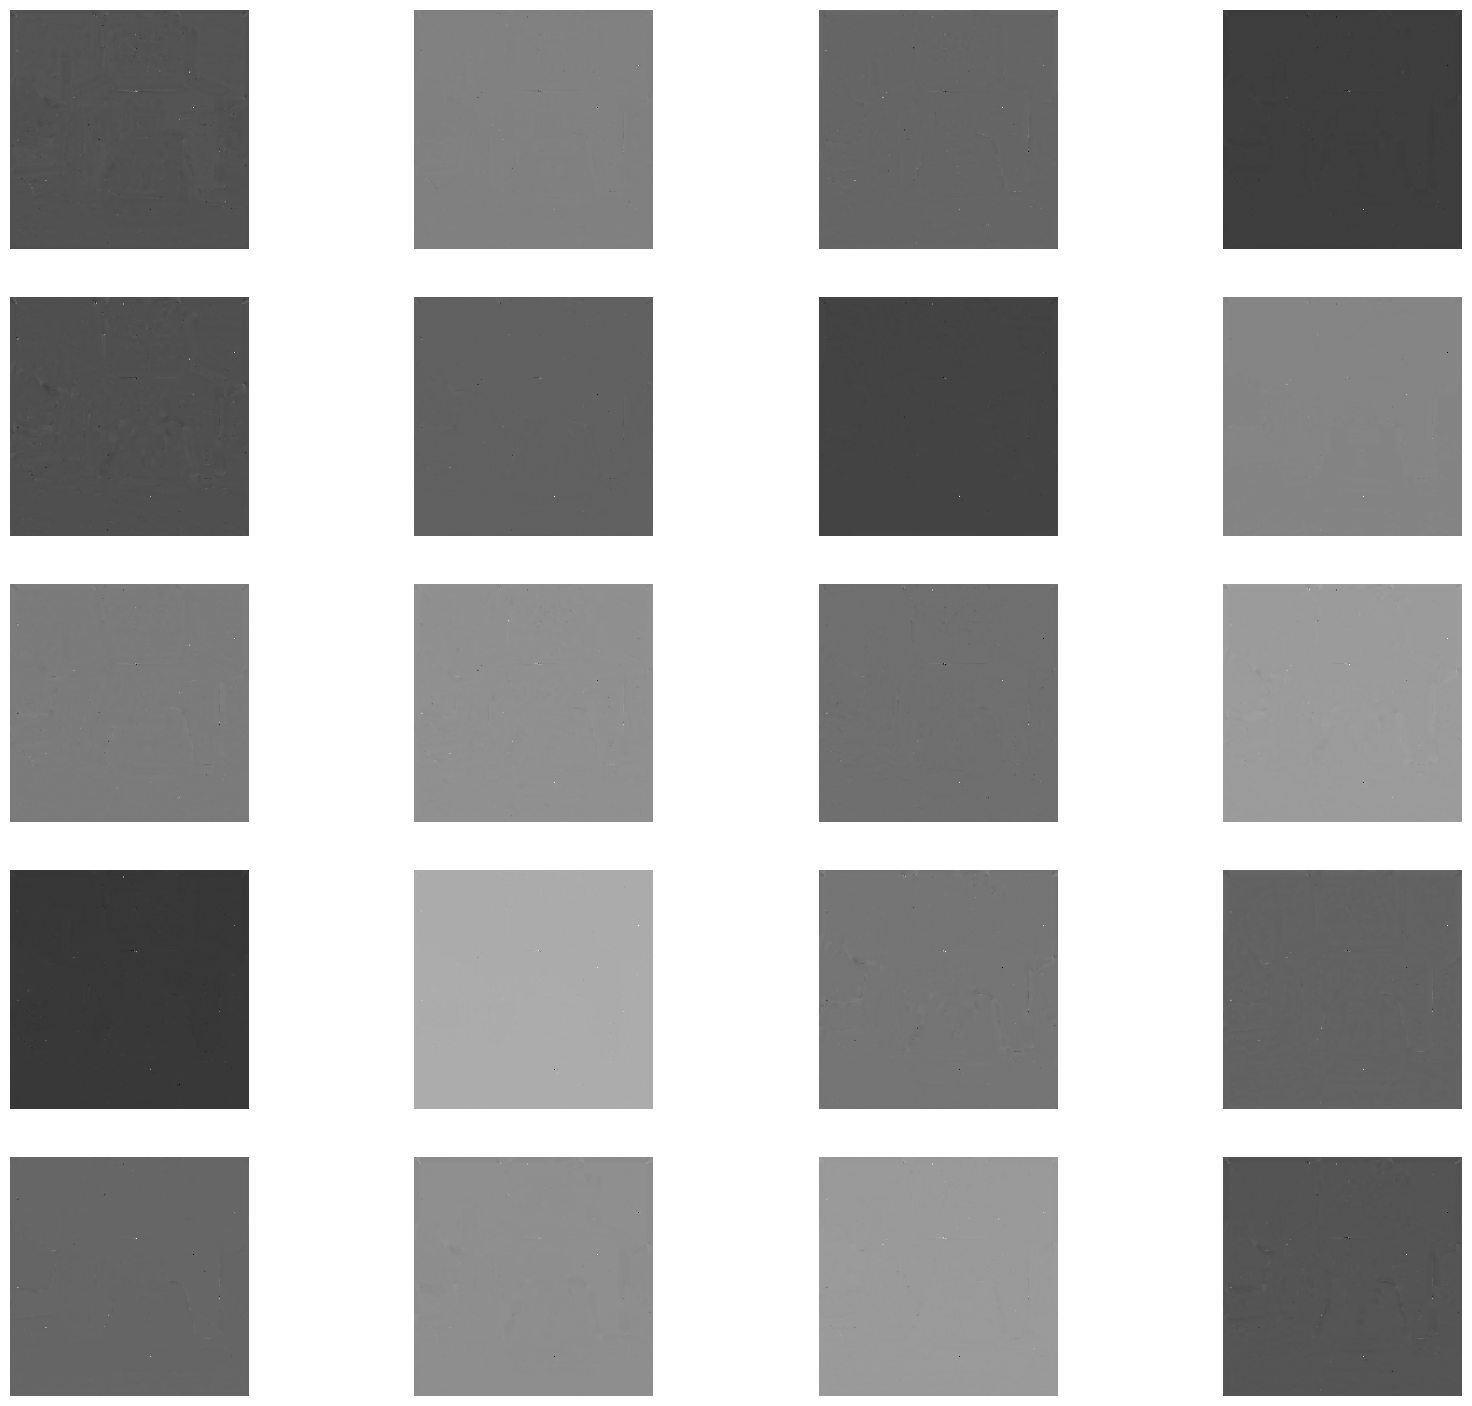

(18, torch.Size([1, 20, 256, 256]), 2)

In [16]:
# Plot the different invariant channels comming from flexi layer
results = flexi_layer(x)
fig, axs = plt.subplots(5, 4, figsize=(20, 18))
for i in range(5):
    for j in range(4):
        if i * 4 + j < results.shape[1]:
            axs[i, j].imshow(results[0, i * 4 + j].detach().cpu(), cmap='gray')
        axs[i, j].axis('off') 
plt.show()
flexi_layer.invariant_cnt, results.shape, flexi_layer._symmetric_cnt

In [17]:
from hippy2d.flexibleconv2d import FlexInv2D
x_rgb = rearrange(test_rgb_img, 'c h w -> 1 c h w').to(dtype=get_default_complex())
rot_x_rgb = torch.rot90(x_rgb, 1, [2, 3]).to(dtype=get_default_complex())

flexi_rgb = FlexInv2D(
    in_channels=3,
    out_channels=20,
    filter_size=FILTER_SIZE,
    max_order=MAX_ORDER
)

torch.testing.assert_close(flexi_rgb(x_rgb), 
                           torch.rot90(flexi_rgb(rot_x_rgb), k=-1, dims=[-2, -1]))

In [18]:
from hippy2d.flexibleconv2d import FlexBaseBlock
x_rgb = rearrange(test_rgb_img, 'c h w -> 1 c h w')
rot_x_rgb = torch.rot90(x_rgb, 1, [2, 3])

test_block = FlexBaseBlock(in_channels=3, out_channels=20, input_size=256)

torch.testing.assert_close(test_block(x_rgb), 
                           torch.rot90(test_block(rot_x_rgb), k=-1, dims=[-2, -1]))

In [24]:
from hippy2d.models import FlexInvCNN
flex_net = FlexInvCNN(in_channels=3, input_size=256, num_classes=10)
flex_net.eval()
flex_net(x_rgb), flex_net(rot_x_rgb)

(tensor([[ 0.0929,  0.0158,  0.0482,  0.1392,  0.0481, -0.0740,  0.0735, -0.1137,
           0.0801,  0.0842]], grad_fn=<AddmmBackward0>),
 tensor([[ 0.0907,  0.0194,  0.0584,  0.1452,  0.0497, -0.0815,  0.0790, -0.1061,
           0.0819,  0.0818]], grad_fn=<AddmmBackward0>))

In [ ]:
flex_net(x_rgb)

In [ ]:
flex_net(rot_x_rgb)